<h1 style="text-align: center; font-size: 30px;">Global Climate Change </h1>

# Introduction & Problem Statement

Climate change is one of the most pressing global challenges of our time. This project performs an
end-to-end **Exploratory Data Analysis (EDA)** on a climate dataset spanning **1940 to 2040**, covering
**30 countries** across **6 regions**, under **4 different scenarios**.

**Objective:** Understand how CO2 emissions, temperature anomalies, renewable energy adoption,
sea level, methane concentration, and extreme weather events evolve over time — and how they
differ depending on the climate policy path.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('climate_dataset_extended_1940_2040.csv')
df.head()

,Year,Country,Region,Scenario,CO2_Emissions_mt,Temp_Anomaly_C,Renewable_Energy_%,Extreme_Events,Climate_Policy_Index,GDP_Billion,Population_Million,Sea_Level_mm,Methane_ppb
0,1940,USA,North America,Historical,215.03,-0.223,4.74,1,10.0,1477.39,181.60,2.71,1104.84
1,1940,USA,North America,Current (2020-2026),203.60,-0.391,2.00,1,10.0,1477.39,181.60,7.33,1095.48
2,1940,USA,North America,BAU,240.88,-0.193,2.00,1,10.0,1477.39,181.60,1.88,1087.99
3,1940,USA,North America,Green,143.95,-0.229,5.56,1,10.0,1477.39,181.60,4.11,1075.58
4,1941,USA,North America,Historical,192.04,-0.159,2.00,1,10.0,1480.10,182.08,3.36,1102.69


In [4]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 12120 rows, 13 columns


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  12120 non-null  int64  
 1   Country               12120 non-null  object 
 2   Region                12120 non-null  object 
 3   Scenario              12120 non-null  object 
 4   CO2_Emissions_mt      12120 non-null  float64
 5   Temp_Anomaly_C        12120 non-null  float64
 6   Renewable_Energy_%    12120 non-null  float64
 7   Extreme_Events        12120 non-null  int64  
 8   Climate_Policy_Index  12120 non-null  float64
 9   GDP_Billion           12120 non-null  float64
 10  Population_Million    12120 non-null  float64
 11  Sea_Level_mm          12120 non-null  float64
 12  Methane_ppb           12120 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Year,CO2_Emissions_mt,Temp_Anomaly_C,Renewable_Energy_%,Extreme_Events,Climate_Policy_Index,GDP_Billion,Population_Million,Sea_Level_mm,Methane_ppb
count,12120.000000,12120.000000,12120.000000,12120.000000,12120.000000,12120.000000,12120.000000,12120.000000,12120.000000,12120.000000
mean,1990.000000,379.781748,0.788369,17.835993,11.968482,21.212415,1290.665157,186.580719,123.461489,1347.089875
std,29.155962,154.570585,0.621508,11.067901,7.699938,15.450237,546.539022,91.509573,76.759424,154.724345
min,1940.000000,40.670000,-0.461000,2.000000,1.000000,10.000000,153.670000,6.460000,-14.270000,1047.990000
25%,1965.000000,261.757500,0.266750,8.430000,5.000000,10.000000,907.717500,116.180000,58.567500,1218.190000
50%,1990.000000,379.500000,0.755500,17.270000,11.000000,10.000000,1266.385000,185.775000,118.420000,1337.185000
75%,2015.000000,499.367500,1.249000,25.940000,18.000000,31.100000,1712.810000,250.630000,180.320000,1461.432500
max,2040.000000,833.400000,2.420000,51.960000,34.000000,86.680000,2813.220000,488.070000,308.550000,1739.700000


In [7]:
df.isnull().sum()


Year                    0
Country                 0
Region                  0
Scenario                0
CO2_Emissions_mt        0
Temp_Anomaly_C          0
Renewable_Energy_%      0
Extreme_Events          0
Climate_Policy_Index    0
GDP_Billion             0
Population_Million      0
Sea_Level_mm            0
Methane_ppb             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Year                      int64
Country                  object
Region                   object
Scenario                 object
CO2_Emissions_mt        float64
Temp_Anomaly_C          float64
Renewable_Energy_%      float64
Extreme_Events            int64
Climate_Policy_Index    float64
GDP_Billion             float64
Population_Million      float64
Sea_Level_mm            float64
Methane_ppb             float64
dtype: object

In [10]:
# Derived columns
df['Decade'] = (df['Year'] // 10) * 10
df['CO2_per_capita'] = df['CO2_Emissions_mt'] / df['Population_Million']
df['GDP_per_capita_USD'] = (df['GDP_Billion'] / df['Population_Million']) * 1000
df['Emissions_per_GDP'] = df['CO2_Emissions_mt'] / df['GDP_Billion']
df.head()

,Year,Country,Region,Scenario,CO2_Emissions_mt,Temp_Anomaly_C,Renewable_Energy_%,Extreme_Events,Climate_Policy_Index,GDP_Billion,Population_Million,Sea_Level_mm,Methane_ppb,Decade,CO2_per_capita,GDP_per_capita_USD,Emissions_per_GDP
0,1940,USA,North America,Historical,215.03,-0.223,4.74,1,10.0,1477.39,181.60,2.71,1104.84,1940,1.184086,8135.407489,0.145547
1,1940,USA,North America,Current (2020-2026),203.60,-0.391,2.00,1,10.0,1477.39,181.60,7.33,1095.48,1940,1.121145,8135.407489,0.137811
2,1940,USA,North America,BAU,240.88,-0.193,2.00,1,10.0,1477.39,181.60,1.88,1087.99,1940,1.326432,8135.407489,0.163044
3,1940,USA,North America,Green,143.95,-0.229,5.56,1,10.0,1477.39,181.60,4.11,1075.58,1940,0.792676,8135.407489,0.097435
4,1941,USA,North America,Historical,192.04,-0.159,2.00,1,10.0,1480.10,182.08,3.36,1102.69,1940,1.054701,8128.844464,0.129748


In [11]:
# Filter/aggregate example
green_future = df[(df['Scenario'] == 'Green') & (df['Year'] >= 2020)]
green_future

,Year,Country,Region,Scenario,CO2_Emissions_mt,Temp_Anomaly_C,Renewable_Energy_%,Extreme_Events,Climate_Policy_Index,GDP_Billion,Population_Million,Sea_Level_mm,Methane_ppb,Decade,CO2_per_capita,GDP_per_capita_USD,Emissions_per_GDP
323,2020,USA,North America,Green,307.54,0.765,35.55,13,45.59,2260.16,305.02,139.69,1389.59,2020,1.008262,7409.874762,0.136070
327,2021,USA,North America,Green,315.72,0.756,34.36,16,45.22,1676.31,254.13,150.44,1377.08,2020,1.242356,6596.269626,0.188342
331,2022,USA,North America,Green,352.24,1.111,36.83,14,41.56,1885.53,292.89,144.58,1365.05,2020,1.202636,6437.672846,0.186812
335,2023,USA,North America,Green,311.42,1.085,39.14,10,47.39,1705.66,266.57,140.57,1377.14,2020,1.168248,6398.544472,0.182580
339,2024,USA,North America,Green,300.25,1.009,40.47,13,45.83,2183.96,252.58,144.32,1401.17,2020,1.188732,8646.607016,0.137480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12103,2036,Peru,South America,Green,414.06,1.272,39.58,17,72.97,1565.96,192.12,161.39,1393.57,2030,2.155215,8150.947325,0.264413
12107,2037,Peru,South America,Green,375.22,1.402,46.35,14,72.43,1730.59,100.72,165.22,1450.27,2030,3.725377,17182.188245,0.216816
12111,2038,Peru,South America,Green,378.78,0.976,47.12,17,71.40,1676.72,100.51,168.19,1437.99,2030,3.768580,16682.121182,0.225905
12115,2039,Peru,South America,Green,399.10,1.212,44.35,17,60.07,1509.38,170.51,177.16,1453.39,2030,2.340625,8852.149434,0.264413


In [12]:
region_avg_temp = df.groupby('Region', observed=True)['Temp_Anomaly_C'].mean().sort_values(ascending=False)
region_avg_temp

Region
North America    0.791814
Africa           0.791418
South America    0.788328
Europe           0.788222
Asia             0.787371
Oceania          0.781963
Name: Temp_Anomaly_C, dtype: float64

In [13]:
key_vars = ['CO2_Emissions_mt', 'Temp_Anomaly_C', 'Renewable_Energy_%', 'Sea_Level_mm', 'Methane_ppb']
df[key_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
CO2_Emissions_mt,12120.0,379.781748,154.570585,40.670,261.75750,379.5000,499.3675,833.40
Temp_Anomaly_C,12120.0,0.788369,0.621508,-0.461,0.26675,0.7555,1.2490,2.42
Renewable_Energy_%,12120.0,17.835993,11.067901,2.000,8.43000,17.2700,25.9400,51.96
Sea_Level_mm,12120.0,123.461489,76.759424,-14.270,58.56750,118.4200,180.3200,308.55
Methane_ppb,12120.0,1347.089875,154.724345,1047.990,1218.19000,1337.1850,1461.4325,1739.70


In [14]:
corr_co2_temp = df['CO2_Emissions_mt'].corr(df['Temp_Anomaly_C'])
print(f"CO2 vs Temp Anomaly correlation: {corr_co2_temp:.3f}")

CO2 vs Temp Anomaly correlation: 0.460


In [15]:
numeric_cols = ['CO2_Emissions_mt','Temp_Anomaly_C','Renewable_Energy_%','Extreme_Events',
                'Climate_Policy_Index','GDP_Billion','Population_Million','Sea_Level_mm',
                'Methane_ppb','CO2_per_capita','GDP_per_capita_USD']
corr_matrix = df[numeric_cols].corr()
corr_matrix

,CO2_Emissions_mt,Temp_Anomaly_C,Renewable_Energy_%,Extreme_Events,Climate_Policy_Index,GDP_Billion,Population_Million,Sea_Level_mm,Methane_ppb,CO2_per_capita,GDP_per_capita_USD
CO2_Emissions_mt,1.000000,0.460052,0.172359,0.451688,0.185023,0.019529,0.066431,0.463313,0.461024,0.266919,0.012510
Temp_Anomaly_C,0.460052,1.000000,0.728358,0.956028,0.682673,0.295899,0.313635,0.984910,0.978854,-0.084478,-0.126968
Renewable_Energy_%,0.172359,0.728358,1.000000,0.709104,0.852472,0.289996,0.308037,0.737290,0.731628,-0.149299,-0.121917
Extreme_Events,0.451688,0.956028,0.709104,1.000000,0.671581,0.290207,0.309706,0.966406,0.960674,-0.082320,-0.123084
Climate_Policy_Index,0.185023,0.682673,0.852472,0.671581,1.000000,0.267331,0.282403,0.690940,0.685948,-0.105730,-0.089801
GDP_Billion,0.019529,0.295899,0.289996,0.290207,0.267331,1.000000,0.040031,0.298506,0.296583,-0.109580,0.322170
Population_Million,0.066431,0.313635,0.308037,0.309706,0.282403,0.040031,1.000000,0.317407,0.313767,-0.528321,-0.618549
Sea_Level_mm,0.463313,0.984910,0.737290,0.966406,0.690940,0.298506,0.317407,1.000000,0.989376,-0.085159,-0.127604
Methane_ppb,0.461024,0.978854,0.731628,0.960674,0.685948,0.296583,0.313767,0.989376,1.000000,-0.084410,-0.126190
CO2_per_capita,0.266919,-0.084478,-0.149299,-0.082320,-0.105730,-0.109580,-0.528321,-0.085159,-0.084410,1.000000,0.785989


In [16]:
pivot_temp = df.pivot_table(values='Temp_Anomaly_C', index='Region', columns='Scenario',
                             aggfunc='mean', observed=True)
pivot_temp.round(2)

Scenario,BAU,Current (2020-2026),Green,Historical
Region,,,,
Africa,1.00,0.86,0.50,0.80
Asia,1.00,0.85,0.50,0.80
Europe,1.00,0.85,0.50,0.81
North America,1.00,0.86,0.50,0.81
Oceania,1.01,0.84,0.49,0.79
South America,1.00,0.86,0.50,0.80


In [17]:
decade_summary = df.groupby('Decade', observed=True).agg(
    Avg_CO2=('CO2_Emissions_mt','mean'),
    Avg_Temp_Anomaly=('Temp_Anomaly_C','mean'),
    Avg_Renewable=('Renewable_Energy_%','mean'),
    Avg_SeaLevel=('Sea_Level_mm','mean')
).round(2)
decade_summary

,Avg_CO2,Avg_Temp_Anomaly,Avg_Renewable,Avg_SeaLevel
Decade,,,,
1940,298.17,-0.11,3.07,11.20
1950,315.52,0.08,5.34,35.71
1960,334.05,0.28,8.61,60.56
1970,351.66,0.48,12.25,85.23
1980,369.16,0.68,15.72,109.98
1990,388.22,0.88,19.27,134.71
2000,404.95,1.07,22.83,159.25
2010,424.52,1.28,26.25,183.80
2020,441.85,1.47,29.94,208.74


## VISUALIZATIONS

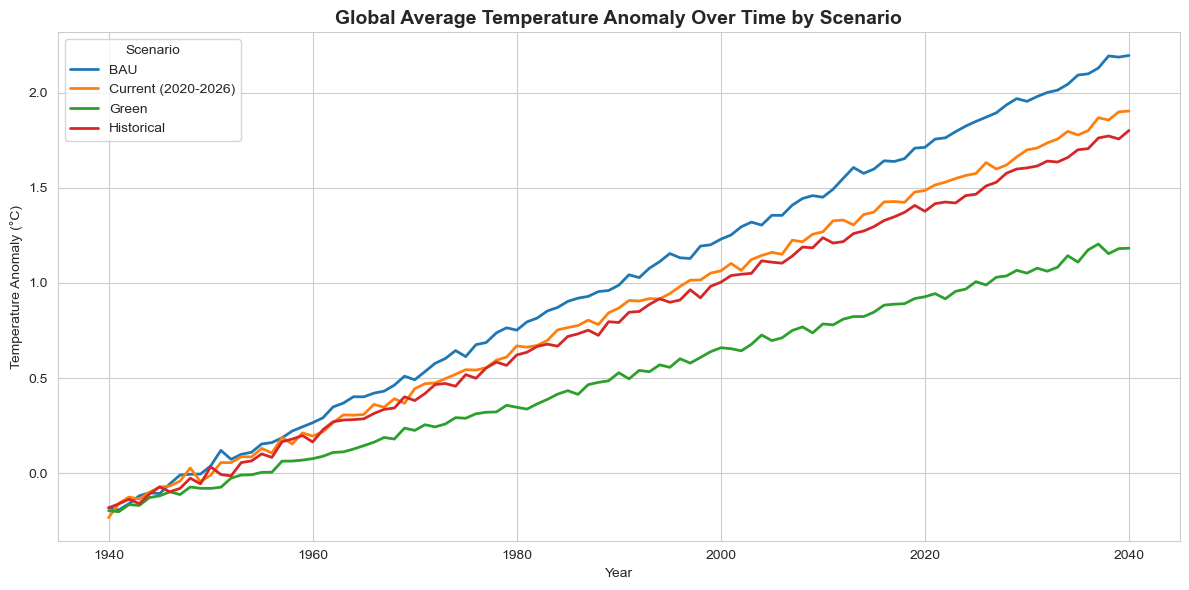

In [19]:
# 1. Temp anomaly over time by scenario
yearly_scenario = df.groupby(['Year','Scenario'], observed=True)['Temp_Anomaly_C'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_scenario, x='Year', y='Temp_Anomaly_C', hue='Scenario', linewidth=2)
plt.title('Global Average Temperature Anomaly Over Time by Scenario', fontsize=14, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Temperature Anomaly (°C)')
plt.tight_layout(); plt.show()

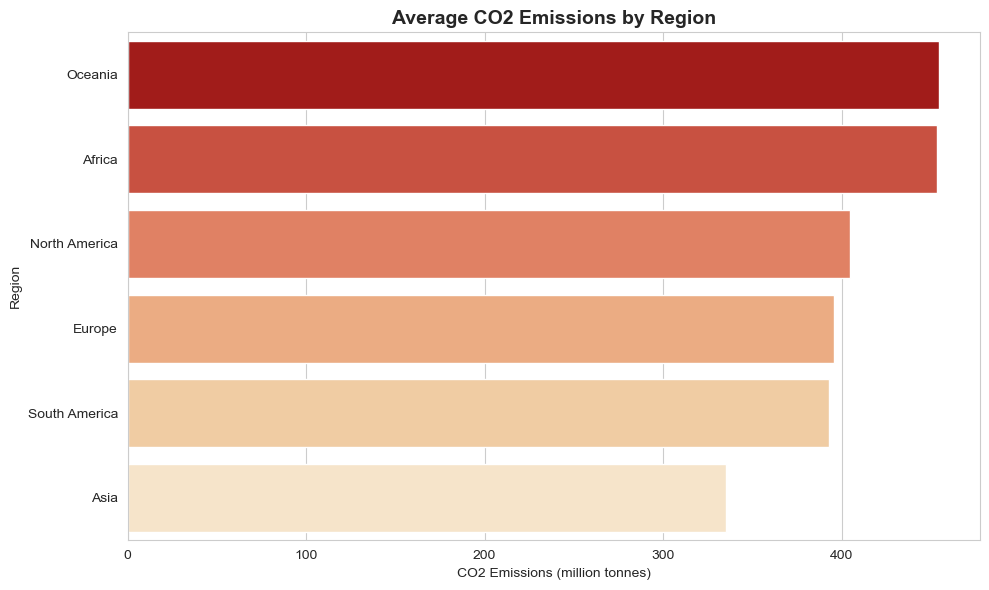

In [20]:
# 2. CO2 emissions by region
region_co2 = df.groupby('Region', observed=True)['CO2_Emissions_mt'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=region_co2.values, y=region_co2.index, hue=region_co2.index, palette='OrRd_r', legend=False)
plt.title('Average CO2 Emissions by Region', fontsize=14, fontweight='bold')
plt.xlabel('CO2 Emissions (million tonnes)'); plt.ylabel('Region')
plt.tight_layout(); plt.show()

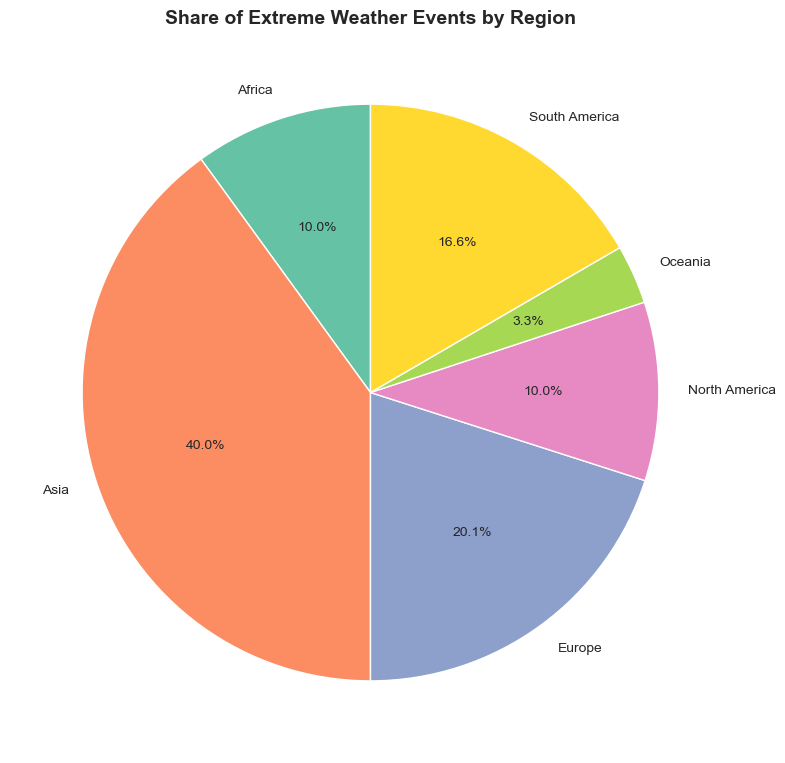

In [21]:
# 3. Extreme events pie chart
events_by_region = df.groupby('Region', observed=True)['Extreme_Events'].sum()
plt.figure(figsize=(8,8))
plt.pie(events_by_region, labels=events_by_region.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'), startangle=90)
plt.title('Share of Extreme Weather Events by Region', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

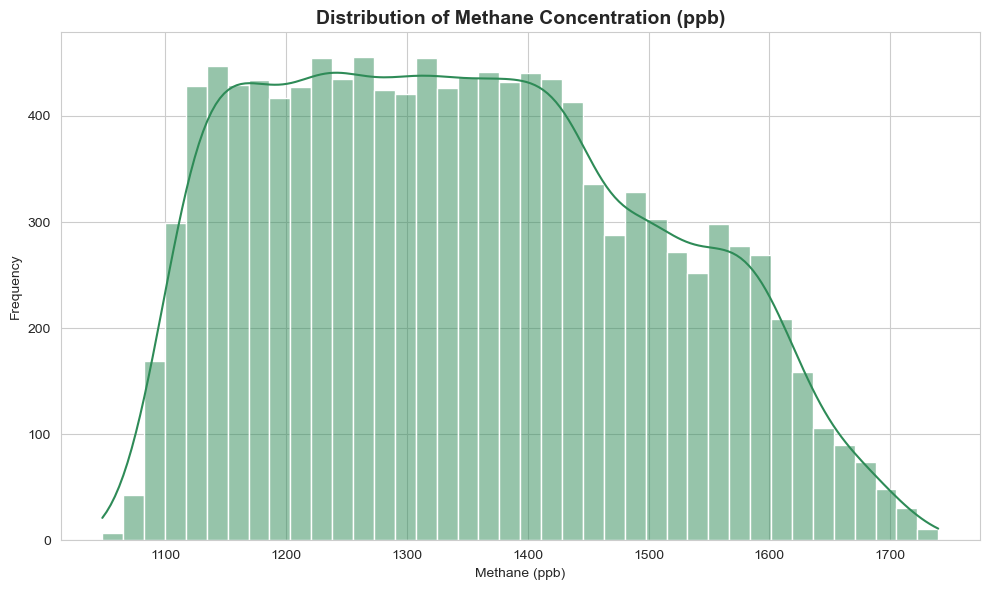

In [22]:
# 4. Methane histogram
plt.figure(figsize=(10,6))
sns.histplot(df['Methane_ppb'], bins=40, kde=True, color='seagreen')
plt.title('Distribution of Methane Concentration (ppb)', fontsize=14, fontweight='bold')
plt.xlabel('Methane (ppb)'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

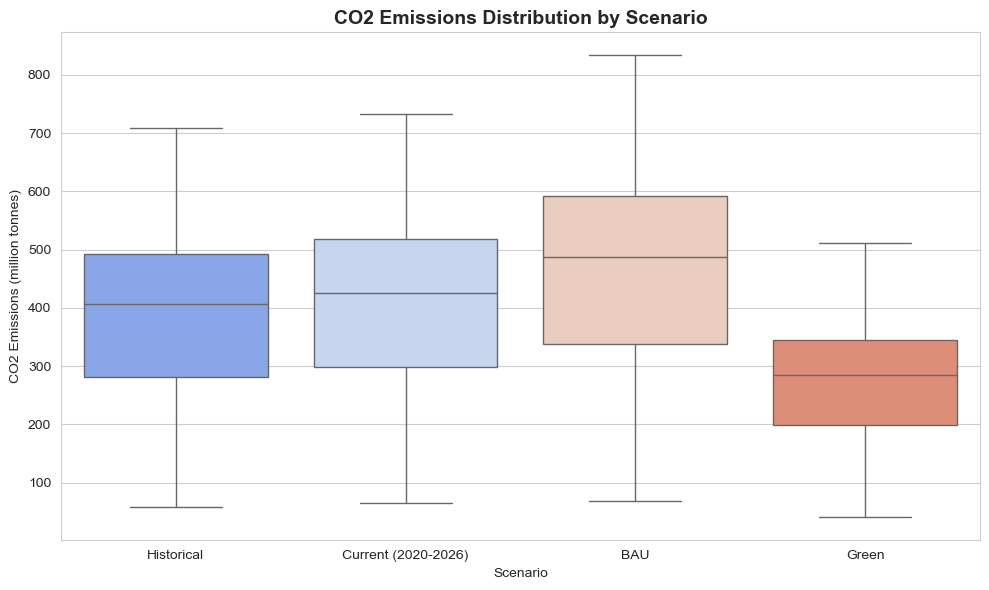

In [23]:
# 5. Box plot by scenario
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Scenario', y='CO2_Emissions_mt', hue='Scenario', palette='coolwarm', legend=False)
plt.title('CO2 Emissions Distribution by Scenario', fontsize=14, fontweight='bold')
plt.xlabel('Scenario'); plt.ylabel('CO2 Emissions (million tonnes)')
plt.tight_layout(); plt.show()

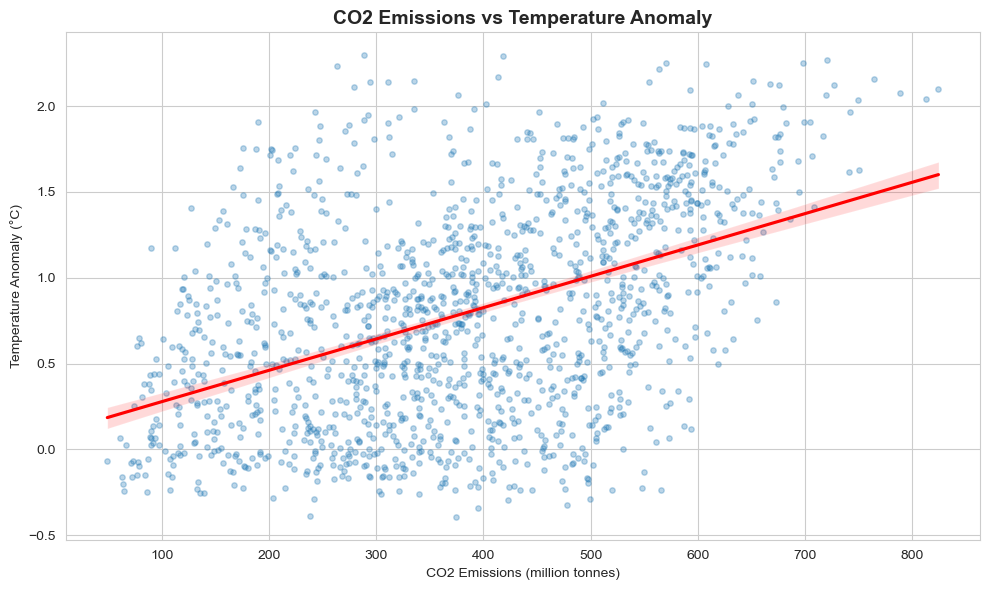

In [24]:
# 6. Scatter + trendline
plt.figure(figsize=(10,6))
sns.regplot(data=df.sample(1500, random_state=42), x='CO2_Emissions_mt', y='Temp_Anomaly_C',
            scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'})
plt.title('CO2 Emissions vs Temperature Anomaly', fontsize=14, fontweight='bold')
plt.xlabel('CO2 Emissions (million tonnes)'); plt.ylabel('Temperature Anomaly (°C)')
plt.tight_layout(); plt.show()

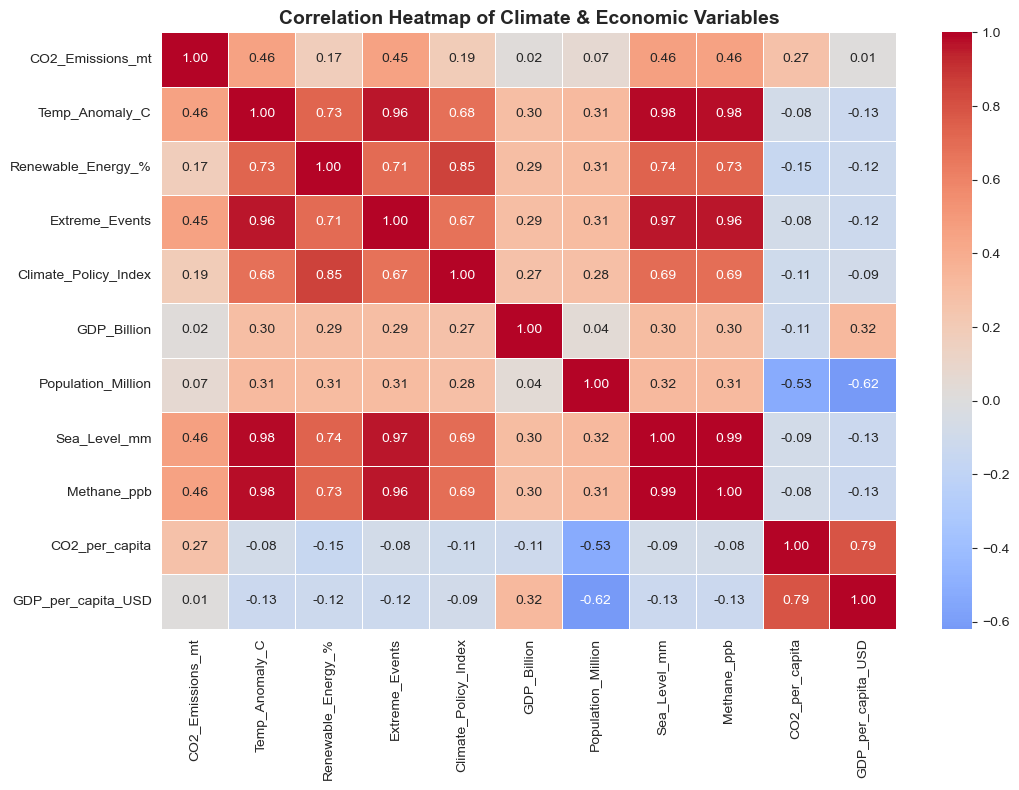

In [25]:
# 7. Correlation heatmap
plt.figure(figsize=(11,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Climate & Economic Variables', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

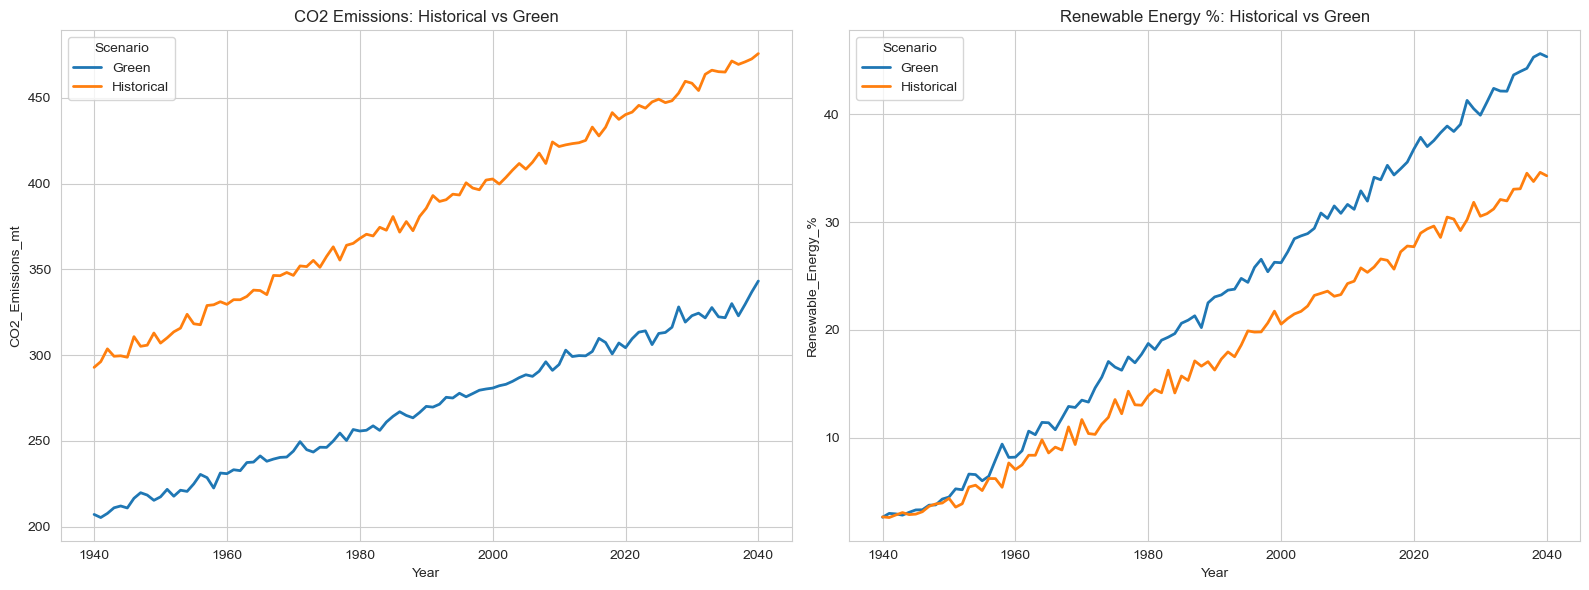

In [26]:
# 8. Historical vs Green subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6))
hist_green = df[df['Scenario'].isin(['Historical','Green'])]
trend1 = hist_green.groupby(['Year','Scenario'], observed=True)['CO2_Emissions_mt'].mean().reset_index()
trend2 = hist_green.groupby(['Year','Scenario'], observed=True)['Renewable_Energy_%'].mean().reset_index()

sns.lineplot(data=trend1, x='Year', y='CO2_Emissions_mt', hue='Scenario', ax=axes[0], linewidth=2)
axes[0].set_title('CO2 Emissions: Historical vs Green')

sns.lineplot(data=trend2, x='Year', y='Renewable_Energy_%', hue='Scenario', ax=axes[1], linewidth=2)
axes[1].set_title('Renewable Energy %: Historical vs Green')

plt.tight_layout(); plt.show()

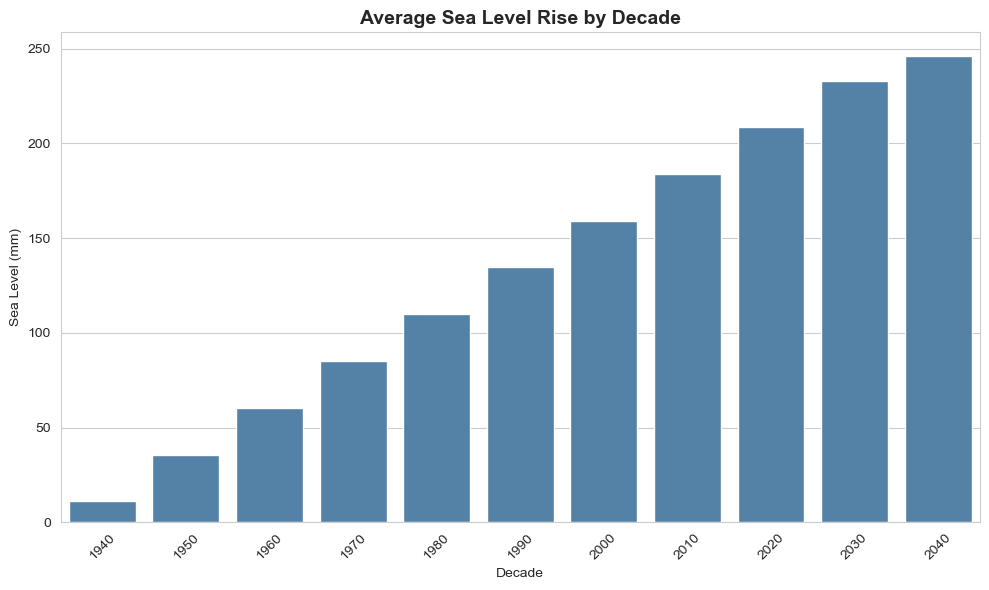

In [27]:
# 9. Sea level rise by decade
plt.figure(figsize=(10,6))
sns.barplot(data=decade_summary.reset_index(), x='Decade', y='Avg_SeaLevel', color='steelblue')
plt.title('Average Sea Level Rise by Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade'); plt.ylabel('Sea Level (mm)')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

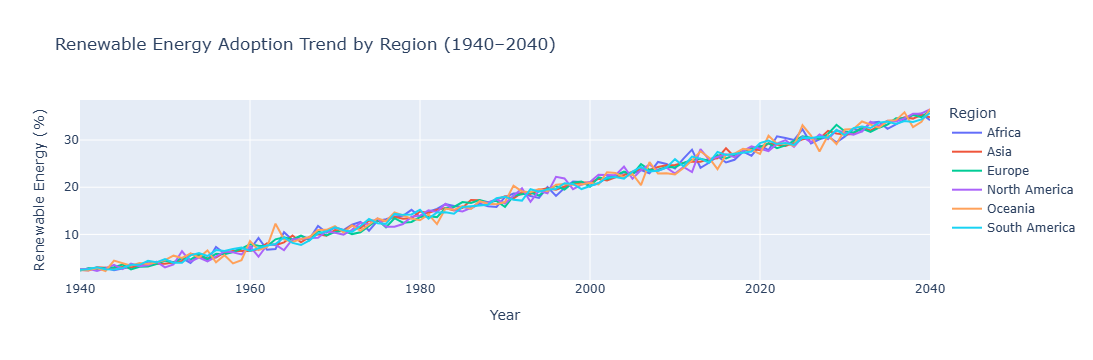

In [28]:
# 10. Interactive renewable energy trend (Plotly)
renew_trend = df.groupby(['Year','Region'], observed=True)['Renewable_Energy_%'].mean().reset_index()
fig = px.line(renew_trend, x='Year', y='Renewable_Energy_%', color='Region',
              title='Renewable Energy Adoption Trend by Region (1940–2040)')
fig.update_layout(xaxis_title='Year', yaxis_title='Renewable Energy (%)')
fig.show()

## 💡 Key Insights

1. **After 2020, the paths split apart.** Green stays cooler, BAU keeps heating up.
2. **More CO2 = more warming.** The data confirms it - they rise together.
3. **Stronger climate policy = more renewable energy.** Countries with tougher rules use more clean power.
4. **Asia and North America pollute the most.** Makes sense — they have the biggest economies and populations.
5. **Sea levels are rising faster over time.** It sped up a lot after the 2000s.
6. **Extreme weather isn't spread out evenly.** Some regions get hit a lot more than others.

## ✅ Conclusion

### What We Found
- CO2, temperature, and sea levels have all been rising since 1940
- After 2020, the future looks very different depending on what the world does
- If nothing changes (BAU) → things keep getting worse
- If the world goes green → things stay much more stable

### What Happens in the Future
- If we keep polluting like now, warming keeps getting worse all the way to 2040 and beyond
- If we switch to clean energy and stronger policies, warming slows down a lot
- What we do today decides which future we get